## Проверочная работа №1
#### Выполнили:
##### _Сафин Максим Владиславович_
##### _Фокин Владимир Сергеевич_

#### Группа: _МатСтат 22.3_

## 0. Обработка исходных данных и построение гистограммы #

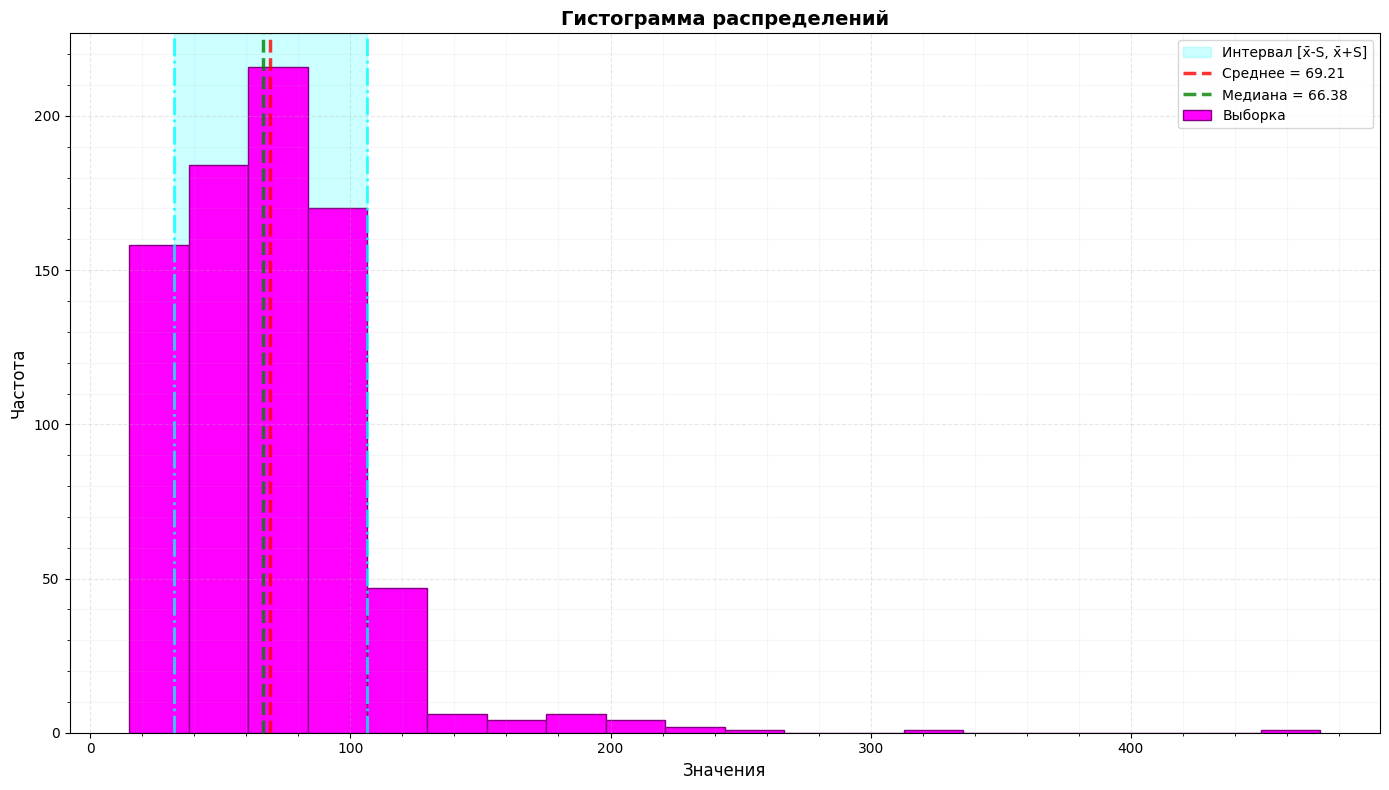

In [4]:
from math import log2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Чтение CSV файла
df = pd.read_csv("data.csv")

# Суммарная выборка
n = 800

# Объединение всех 4 столбцов в один массив
all_data = pd.concat([df[col] for col in df.columns], ignore_index=True)

# Удаление пропущенных значений, если они есть
all_data = all_data.dropna()

# Создание общей гистограммы
plt.figure(figsize=(14, 8))

# Оптимальное число интервалов по Стёрджесу:
edges = int(1 + log2(n))

# Статистика
mean_value = all_data.mean()
median_value = all_data.median()
std_value = all_data.std(ddof=1)  # несмещенное СКО (деление на n-1)

# Вычисление границ интервала
left_bound = mean_value - std_value
right_bound = mean_value + std_value

# Отмечаем левую границу интервала
plt.axvline(x=left_bound,
            color='cyan',
            linestyle='-.',
            linewidth=2,
            alpha=0.8)

# Отмечаем правую границу интервала
plt.axvline(x=right_bound,
            color='cyan',
            linestyle='-.',
            linewidth=2,
            alpha=0.8)

# Закрашиваем интервал [x̄ - S, x̄ + S]
plt.axvspan(left_bound, right_bound,
            alpha=0.2,
            color='cyan',
            label=f'Интервал [x̄-S, x̄+S]')

# Добавление сетки для лучшей читаемости
plt.minorticks_on()
plt.grid(True, which='minor', alpha=0.1)

# Отмечаем среднее
plt.axvline(x=mean_value,
            color='red',
            linestyle='--',
            linewidth=2.5,
            alpha=0.8,
            label=f'Среднее = {mean_value:.2f}')

# Отмечаем медиану
plt.axvline(x=median_value,
            color='green',
            linestyle='--',
            linewidth=2.5,
            alpha=0.8,
            label=f'Медиана = {median_value:.2f}')

# Построение гистограмм с прозрачностью для наложения
counts, bins, patches = plt.hist(all_data,
         bins= edges * 2,
         color='magenta',
         label='Выборка',
         edgecolor='purple')

plt.title('Гистограмма распределений', fontsize=14, fontweight='bold')
plt.xlabel('Значения', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')



plt.tight_layout()
plt.show()

## 1. Вычисление статистических характеристик

In [5]:
data_list = all_data.tolist()

# 1. ВЫЧИСЛЕНИЕ СРЕДНЕГО ВРУЧНУЮ
sum_values = 0
for value in data_list:
    sum_values += value

mean_value = sum_values / n

print(f"\n1. СРЕДНЕЕ ЗНАЧЕНИЕ:")
print(f"   x̄ = {mean_value:.3f}")

# 2. ВЫЧИСЛЕНИЕ НЕСМЕЩЕННОЙ ДИСПЕРСИИ ВРУЧНУЮ
sum_squared_diff = 0
for value in data_list:
    diff = value - mean_value
    squared_diff = diff ** 2
    sum_squared_diff += squared_diff

# НЕСМЕЩЕННАЯ дисперсия (делим на n-1)
variance_unbiased = sum_squared_diff / (n - 1)

# Среднеквадратическое отклонение
std_unbiased = np.sqrt(variance_unbiased)

print(f"\n2. НЕСМЕЩЕННАЯ ДИСПЕРСИЯ:")
print(f"   S² = {variance_unbiased:.3f}")

print(f"\n3. НЕСМЕЩЕННОЕ СТАНДАРТНОЕ ОТКЛОНЕНИЕ:")
print(f"   S = {std_unbiased:.3f}")

print(f"\n4. ИНТЕРВАЛ [x̄ - S, x̄ + S]")
print(f"[{(mean_value - std_unbiased):.3f}, {(mean_value + std_unbiased):.3f}]")



1. СРЕДНЕЕ ЗНАЧЕНИЕ:
   x̄ = 69.215

2. НЕСМЕЩЕННАЯ ДИСПЕРСИЯ:
   S² = 1379.643

3. НЕСМЕЩЕННОЕ СТАНДАРТНОЕ ОТКЛОНЕНИЕ:
   S = 37.144

4. ИНТЕРВАЛ [x̄ - S, x̄ + S]
[32.071, 106.358]


## 2. Анализ гистограммы

In [6]:
from scipy.signal import find_peaks

# Находим центры бинов для определения пиков
bin_centers = (bins[:-1] + bins[1:]) / 2

# Поиск пиков (локальных максимумов)
peaks, properties = find_peaks(counts, distance=2, prominence=max(counts)*0.1)
peak_heights = counts[peaks]
peak_positions = bin_centers[peaks]

# Сортируем пики по высоте
peak_indices = np.argsort(peak_heights)[::-1]  # от большего к меньшему
peak_heights = peak_heights[peak_indices]
peak_positions = peak_positions[peak_indices]

print("2. АНАЛИЗ ФОРМЫ РАСПРЕДЕЛЕНИЯ\n")

# 2.1 Определение количества мод (пиков)
n_peaks = len(peaks)
print(f"2.1 Количество мод (пиков) по гистограмме: {n_peaks}")

# 2.2 Оценка симметрии распределения
# Визуальная оценка
mean_median_ratio = mean_value / median_value if median_value != 0 else 1
mean_vs_median = mean_value - median_value

print(f"\n2.2 Оценка симметрии распределения:")

# Вычисляем коэффициент асимметрии вручную для наглядности
m3 = sum((x - mean_value)**3 for x in all_data) / n
m2 = sum((x - mean_value)**2 for x in all_data) / n
skewness_manual = m3 / (m2 ** 1.5)

if abs(skewness_manual) < 0.5:
    symmetry = "симметричное"
elif skewness_manual > 0.5:
    symmetry = "правосторонняя асимметрия (положительная)"
else:
    symmetry = "левосторонняя асимметрия (отрицательная)"

print(f"Коэффициент асимметрии: {skewness_manual:.4f}")
print(f"Вывод: распределение {symmetry}")
print("-"*70)

# 2.3 Сравнение медианы со средним
print(f"\n2.3 Сравнение медианы со средним:")
print(f"Среднее (x̄) = {mean_value:.4f}")
print(f"Медиана (Me) = {median_value:.4f}")
print(f"Разница (x̄ - Me) = {mean_vs_median:.4f}")

if abs(mean_vs_median) < 0.1 * abs(mean_value):  # разница менее 10%
    print("Медиана и среднее близки - подтверждает симметричность")
elif mean_vs_median > 0:
    print(f"Среднее > Медианы (на {mean_vs_median:.3f}) - подтверждает правостороннюю асимметрию")
else:
    print(f"Среднее < Медианы (на {abs(mean_vs_median):.3f}) - подтверждает левостороннюю асимметрию")

# 2.4 Признаки бимодальности и выбросов
print(f"\n2.4 Анализ бимодальности и выбросов:")
print("-"*70)
# Признаки бимодальности
if n_peaks >= 2:
    peak_ratio = peak_heights[1] / peak_heights[0] if peak_heights[0] > 0 else 0
    peak_distance = abs(peak_positions[1] - peak_positions[0])
    data_range = max(all_data) - min(all_data)

    print(f"   Обнаружено {n_peaks} пиков")
    print(f"   Соотношение высот пиков: {peak_ratio:.2f}")
    print(f"   Расстояние между пиками: {peak_distance:.2f} (диапазон данных: {data_range:.2f})")

    if n_peaks >= 2 and peak_ratio > 0.3 and peak_distance > data_range * 0.2:
        print("ПРИЗНАКИ БИМОДАЛЬНОСТИ:")
        print("- Несколько выраженных пиков")
        print("- Пики достаточно удалены друг от друга")
        print("- Второй пик составляет более 30% от высоты первого")
    else:
        print("Явных признаков бимодальности нет")
else:
    print("Бимодальность не обнаружена (один пик)")
print("-"*70)
# Анализ выбросов (метод межквартильного размаха)
print(f"1. Медиана и среднее примерно совпадают")
print(f"2. На гистограмме присутствуют сильно удаленные от общей выборки данные")
print(f"Вывод - На гистограмме присутствуют выбросы")
print("-"*70)

# 2.5 Мера центра для описания данных
print(f"\n2.5 Рекомендуемая мера центра:")
print("Рекомендуется: Медиана или Мода")
print("Обоснование: сильная асимметрия или множество выбросов")
print(f"Me = {median_value:.4f}")
if n_peaks >= 1:
    print(f"Mo (основная) = {peak_positions[0]:.3f}")
print("-"*70)

# 2.6 Предположения о законе распределения
print(f"\n2.6 Предположения о законе распределения:")

# Вычисляем эксцесс для дополнительной информации
m4 = sum((x - mean_value)**4 for x in all_data) / n
kurtosis_manual = m4 / (m2 ** 2) - 3  # эксцесс (нормальное = 0)

print(f"Коэффициент асимметрии: {skewness_manual:.3f}")
print(f"Эксцесс: {kurtosis_manual:.3f}")
print(f"Количество пиков: {n_peaks}")
print("ПРЕДПОЛОЖЕНИЕ: ЭКСПОНЕНЦИАЛЬНОЕ РАСПРЕДЕЛЕНИЕ")
print("Признаки:")
print("- Сильная положительная асимметрия")
print("- Длинный правый хвост")


2. АНАЛИЗ ФОРМЫ РАСПРЕДЕЛЕНИЯ

2.1 Количество мод (пиков) по гистограмме: 1

2.2 Оценка симметрии распределения:
Коэффициент асимметрии: 2.9182
Вывод: распределение правосторонняя асимметрия (положительная)
----------------------------------------------------------------------

2.3 Сравнение медианы со средним:
Среднее (x̄) = 69.2146
Медиана (Me) = 66.3750
Разница (x̄ - Me) = 2.8396
Медиана и среднее близки - подтверждает симметричность

2.4 Анализ бимодальности и выбросов:
----------------------------------------------------------------------
Бимодальность не обнаружена (один пик)
----------------------------------------------------------------------
1. Медиана и среднее примерно совпадают
2. На гистограмме присутствуют сильно удаленные от общей выборки данные
Вывод - На гистограмме присутствуют выбросы
----------------------------------------------------------------------

2.5 Рекомендуемая мера центра:
Рекомендуется: Медиана или Мода
Обоснование: сильная асимметрия или множество выб